# Voice Command AI — Training Pipeline
**Proyecto 1 — IA I-2026 | TEC Costa Rica**

Pipeline completo:
1. Dataset — Google Speech Commands v2
2. Preprocesamiento — Mel Spectrogram (64×101)
3. SpecAugment (Park et al. 2019)
4. Modelo A — LeNet-5 adaptado
5. Modelo B — MobileNetV3-Small adaptado
6. 12 runs WandB (3 por combinación)
7. Exportación ONNX (opset 17)
8. Validación numérica ONNX vs PyTorch

In [ ]:
# ── Instalar dependencias ────────────────────────────────────────────────────
%pip install torch torchaudio torchvision wandb onnx onnxscript onnxruntime scikit-learn matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.3 MB/s eta 0:00:00


In [ ]:
import random
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import wandb
import onnx
import onnxruntime as ort
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from collections import Counter

# ── WandB login ─────────────────────────────────────────────────────────────
wandb.login(key="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")

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: adbyb-es (ai-allan-david) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Device: cuda


## 1. Dataset — Speech Commands v2

In [ ]:
# ── Constantes ──────────────────────────────────────────────────────────────
SAMPLE_RATE = 16000
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 160
TARGET_LEN = 16000  # 1 segundo

# 12 clases: 10 comandos + _silence_ + _unknown_
# Orden fijo — debe coincidir con VoiceCommand.labels en la app Flutter
TARGET_CLASSES = [
    'yes', 'no', 'up', 'down', 'left', 'right',
    'on', 'off', 'stop', 'go',
    '_silence_', '_unknown_',
]
COMMAND_CLASSES = set(TARGET_CLASSES[:10])   # solo los 10 comandos
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)  # 12

# torchaudio descarga a data/SpeechCommands/speech_commands_v0.02/
DATA_DIR = Path('data/SpeechCommands/speech_commands_v0.02')

if not DATA_DIR.exists():
    print('Descargando Speech Commands v2 (~2.3 GB)...')
    Path('data/').mkdir(parents=True, exist_ok=True)
    torchaudio.datasets.SPEECHCOMMANDS(root='data/', download=True, subset='training')
    print('Dataset descargado.')
else:
    print('Dataset ya existe.')


Descargando Speech Commands v2 (~2.3 GB)...


100%|██████████| 2.26G/2.26G [00:11<00:00, 219MB/s]


Dataset descargado.


In [ ]:
# ── Transformaciones ────────────────────────────────────────────────────────
mel_transform = nn.Sequential(
    T.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        f_min=20.0,
        f_max=8000.0,
    ),
    T.AmplitudeToDB(),
)

def pad_or_trim(waveform, target_len=TARGET_LEN):
    if waveform.shape[-1] < target_len:
        waveform = F.pad(waveform, (0, target_len - waveform.shape[-1]))
    else:
        waveform = waveform[..., :target_len]
    return waveform

def to_spectrogram(waveform):
    waveform = pad_or_trim(waveform)
    spec = mel_transform(waveform)  # [1, 64, 101]
    return spec

# ── Estadísticas de normalización ───────────────────────────────────────────
# Calculadas sobre todas las clases (comandos + silencio + desconocido)
# para que la normalización sea representativa del input real de producción.
def compute_norm_stats(n_samples=2000):
    """Muestrea n_samples espectrogramas del set de entrenamiento (todas las clases)."""
    specs = []
    raw = torchaudio.datasets.SPEECHCOMMANDS('data/', subset='training')
    indices = random.sample(range(len(raw)), min(n_samples, len(raw)))
    for i in indices:
        waveform, sr, label, *_ = raw[i]
        spec = to_spectrogram(waveform)
        specs.append(spec)

    # Añadir algunos clips de ruido de fondo para representar _silence_
    noise_dir = DATA_DIR / '_background_noise_'
    if noise_dir.exists():
        for nf in list(noise_dir.glob('*.wav'))[:4]:
            waveform, sr = torchaudio.load(nf)
            if sr != SAMPLE_RATE:
                waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
            for _ in range(50):
                start = random.randint(0, max(0, waveform.shape[-1] - TARGET_LEN))
                clip = waveform[..., start:start + TARGET_LEN]
                specs.append(to_spectrogram(clip))

    data = torch.stack(specs)
    mean = data.mean().item()
    std  = data.std().item()
    return mean, std

print('Calculando estadísticas de normalización...')
NORM_MEAN, NORM_STD = compute_norm_stats(n_samples=2000)
print(f'mean={NORM_MEAN:.4f}, std={NORM_STD:.4f}')

with open('norm_stats.json', 'w') as f:
    json.dump({'mean': NORM_MEAN, 'std': NORM_STD}, f, indent=2)
print('norm_stats.json guardado.')


Calculando estadísticas de normalización...
mean=-21.6562, std=23.8955
norm_stats.json guardado.


In [ ]:
# ── Dataset PyTorch — 12 clases ──────────────────────────────────────────────
#
# _silence_: clips de 1s extraídos de _background_noise_/ + zeros puros
# _unknown_: palabras del dataset que NO son los 10 comandos (submuestreado)
# El número de muestras de _silence_ y _unknown_ se calibra para igualar
# el promedio de muestras por clase de los 10 comandos → dataset balanceado.

def _build_silence_samples(n: int, rng: random.Random) -> list:
    """Genera n clips de silencio/ruido de fondo (tensor [1, 16000])."""
    samples = []
    noise_dir = DATA_DIR / '_background_noise_'
    noise_clips = []

    if noise_dir.exists():
        for nf in sorted(noise_dir.glob('*.wav')):
            waveform, sr = torchaudio.load(nf)
            if sr != SAMPLE_RATE:
                waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
            # Mono
            if waveform.shape[0] > 1:
                waveform = waveform.mean(0, keepdim=True)
            noise_clips.append(waveform)

    n_from_noise = int(n * 0.85) if noise_clips else 0
    n_zeros = n - n_from_noise

    for _ in range(n_from_noise):
        clip_src = rng.choice(noise_clips)
        total = clip_src.shape[-1]
        if total >= TARGET_LEN:
            start = rng.randint(0, total - TARGET_LEN)
            clip = clip_src[..., start:start + TARGET_LEN]
        else:
            clip = F.pad(clip_src, (0, TARGET_LEN - total))
        samples.append(clip)

    for _ in range(n_zeros):
        samples.append(torch.zeros(1, TARGET_LEN))

    return samples


class SpeechCommandsDataset(Dataset):
    def __init__(self, subset: str, augment: bool = False,
                 norm_mean: float = NORM_MEAN, norm_std: float = NORM_STD):
        self.augment   = augment
        self.norm_mean = norm_mean
        self.norm_std  = norm_std

        rng = random.Random(SEED)  # reproducible por subset

        # ── 1. Leer el split ────────────────────────────────────────────────
        raw = torchaudio.datasets.SPEECHCOMMANDS('data/', subset=subset)

        command_samples = []   # (waveform, label) — 10 comandos
        unknown_pool   = []    # waveforms de palabras no-comando

        for waveform, sr, label, *_ in raw:
            if label in COMMAND_CLASSES:
                command_samples.append((waveform, label))
            elif label != '_background_noise_':
                unknown_pool.append(waveform)

        # ── 2. Calcular cuántas muestras _silence_ / _unknown_ agregar ──────
        # Objetivo: ~mismo número que el promedio de los 10 comandos
        avg_per_cmd = len(command_samples) // 10
        n_silence = avg_per_cmd
        n_unknown = avg_per_cmd

        # ── 3. _silence_ ────────────────────────────────────────────────────
        silence_wavs = _build_silence_samples(n_silence, rng)
        silence_samples = [(w, '_silence_') for w in silence_wavs]

        # ── 4. _unknown_ ────────────────────────────────────────────────────
        rng.shuffle(unknown_pool)
        unknown_wavs = unknown_pool[:n_unknown]
        unknown_samples = [(w, '_unknown_') for w in unknown_wavs]

        # ── 5. Combinar y mezclar ────────────────────────────────────────────
        self.samples = command_samples + silence_samples + unknown_samples
        rng.shuffle(self.samples)

        # SpecAugment (solo para train augmentado)
        self.time_mask = T.TimeMasking(time_mask_param=40)
        self.freq_mask = T.FrequencyMasking(freq_mask_param=27)

        counts = Counter(label for _, label in self.samples)
        print(f'[{subset}{"+" if augment else ""}] {len(self.samples)} muestras | '
              f'cmd={len(command_samples)} sil={len(silence_samples)} unk={len(unknown_samples)}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        waveform, label = self.samples[idx]
        spec = to_spectrogram(waveform)          # [1, 64, 101]
        spec = (spec - self.norm_mean) / (self.norm_std + 1e-8)
        if self.augment:
            spec = self.time_mask(spec)
            spec = self.freq_mask(spec)
        return spec, CLASS_TO_IDX[label]


# ── Crear datasets ────────────────────────────────────────────────────────────
train_base = SpeechCommandsDataset('training',   augment=False)
train_aug  = SpeechCommandsDataset('training',   augment=True)
val_ds     = SpeechCommandsDataset('validation', augment=False)
test_ds    = SpeechCommandsDataset('testing',    augment=False)

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 64
train_base_loader = DataLoader(train_base, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
train_aug_loader  = DataLoader(train_aug,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader        = DataLoader(val_ds,     batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader       = DataLoader(test_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


[training] 36921 muestras | cmd=30769 sil=3076 unk=3076
[training+] 36921 muestras | cmd=30769 sil=3076 unk=3076
[validation] 4443 muestras | cmd=3703 sil=370 unk=370
[testing] 4888 muestras | cmd=4074 sil=407 unk=407


## 2. Modelo A — LeNet-5 adaptado
Entrada: `[batch, 1, 64, 101]`

`Conv2d(1,6,5,pad=2) → AvgPool(2,2) → Conv2d(6,16,5) → AvgPool(2,2) → Flatten → Linear→120 → Linear→84 → Linear→12`

In [ ]:
class LeNet5KWS(nn.Module):
    """LeNet-5 adaptado para KWS (entrada 1×64×101, 12 clases)"""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        # Calcular tamaño dinámico
        dummy = torch.zeros(1, 1, 64, 101)
        feat_size = self.features(dummy).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_size, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Verificar arquitectura
model_a = LeNet5KWS().to(DEVICE)
dummy = torch.zeros(1, 1, 64, 101).to(DEVICE)
out = model_a(dummy)
print(f'LeNet-5 output shape: {out.shape}')  # esperado: [1, 12]
total_params = sum(p.numel() for p in model_a.parameters())
print(f'Parámetros totales: {total_params:,}')

LeNet-5 output shape: torch.Size([1, 12])
Parámetros totales: 632,116


## 3. Modelo B — MobileNetV3-Small adaptado
Primer conv modificado para entrada 1 canal. Justificación: ~2.5M params, diseñado para móvil.

In [ ]:
import torchvision.models as models

def build_mobilenet_v3_kws(num_classes=NUM_CLASSES):
    """MobileNetV3-Small con primer conv adaptado a 1 canal"""
    model = models.mobilenet_v3_small(weights=None)
    # Modificar primer conv: (3,16,3,stride=2) → (1,16,3,stride=2)
    model.features[0][0] = nn.Conv2d(
        in_channels=1, out_channels=16,
        kernel_size=3, stride=2, padding=1, bias=False
    )
    # Modificar cabeza clasificadora para 12 clases
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    return model

model_b = build_mobilenet_v3_kws().to(DEVICE)
out = model_b(dummy)
print(f'MobileNetV3 output shape: {out.shape}')  # esperado: [1, 12]
total_params = sum(p.numel() for p in model_b.parameters())
print(f'Parámetros totales: {total_params:,}')

MobileNetV3 output shape: torch.Size([1, 12])
Parámetros totales: 1,529,868


## 4. Training Loop + WandB

12 runs mínimo:
- **A1-A3**: LeNet-5, dataset base, LR variado
- **A4-A6**: LeNet-5, dataset aumentado, LR/batch variado
- **B1-B3**: MobileNetV3, dataset base, LR variado
- **B4-B6**: MobileNetV3, dataset aumentado

In [ ]:
from torch.cuda.amp import GradScaler, autocast

# GradScaler global — no-op en CPU, activo en GPU
scaler = GradScaler(enabled=torch.cuda.is_available())

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for specs, labels in loader:
        specs, labels = specs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        # ── AMP forward ────────────────────────────────────────────────────
        with autocast(enabled=torch.cuda.is_available()):
            logits = model(specs)
            loss   = criterion(logits, labels)
        # ── AMP backward ───────────────────────────────────────────────────
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * specs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += specs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for specs, labels in loader:
        specs, labels = specs.to(DEVICE), labels.to(DEVICE)
        with autocast(enabled=torch.cuda.is_available()):
            logits = model(specs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * specs.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += specs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total, correct / total, f1, all_preds, all_labels


def run_training(run_name, model_fn, loader, epochs=30, lr=1e-3,
                 optimizer_cls=torch.optim.Adam, scheduler_fn=None,
                 weight_decay=1e-4, patience=6):
    """Entrena con AMP + early stopping (patience épocas sin mejora en val_f1)."""
    wandb.init(project='voice-command-ai', name=run_name,
               config={'lr': lr, 'epochs': epochs, 'optimizer': optimizer_cls.__name__,
                       'weight_decay': weight_decay, 'patience': patience})

    model     = model_fn().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = scheduler_fn(optimizer) if scheduler_fn else None

    best_f1    = 0.0
    best_state = None
    no_improve = 0   # contador early stopping

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = eval_epoch(model, val_loader, criterion)

        if scheduler:
            scheduler.step()

        wandb.log({
            'epoch': epoch,
            'train/loss': train_loss, 'train/acc': train_acc,
            'val/loss':   val_loss,   'val/acc':   val_acc,
            'val/f1_macro': val_f1,
        })

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 5 == 0:
            print(f'[{run_name}] Epoch {epoch:3d} | '
                  f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} '
                  f'val_f1={val_f1:.4f} | best={best_f1:.4f} (no_imp={no_improve})')

        # Early stopping
        if no_improve >= patience:
            print(f'[{run_name}] Early stop en epoch {epoch} (sin mejora por {patience} épocas)')
            break

    # Evaluar mejor checkpoint en test
    model.load_state_dict(best_state)
    _, test_acc, test_f1, test_preds, test_labels = eval_epoch(model, test_loader, criterion)

    cm  = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=ax)
    ax.set_title(f'{run_name} — Confusion Matrix (test)')
    wandb.log({'test/confusion_matrix': wandb.Image(fig),
               'test/acc': test_acc, 'test/f1_macro': test_f1})
    plt.close(fig)

    print(f'[{run_name}] BEST val_f1={best_f1:.4f} | test_acc={test_acc:.4f} test_f1={test_f1:.4f}')
    wandb.finish()
    return model, best_f1, test_f1


/tmp/ipykernel_5560/3787483968.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


In [ ]:
# ── Runs A1-A3: LeNet-5, dataset base ─────────────────────────────────────
results = {}

for run_id, lr in [('A1', 0.01), ('A2', 0.001), ('A3', 0.0001)]:
    model, val_f1, test_f1 = run_training(
        run_name=run_id,
        model_fn=LeNet5KWS,
        loader=train_base_loader,
        lr=lr,
        optimizer_cls=torch.optim.SGD,
    )
    results[run_id] = {'model': model, 'val_f1': val_f1, 'test_f1': test_f1}

/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[A1] Epoch   5 | val_loss=1.1177 val_acc=0.6446 val_f1=0.6372 | best=0.6372 (no_imp=0)


/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[A1] Epoch  10 | val_loss=0.7239 val_acc=0.7738 val_f1=0.7723 | best=0.7723 (no_imp=0)


/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

...

/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[A3] Epoch  30 | val_loss=2.2336 val_acc=0.2703 val_f1=0.2262 | best=0.2262 (no_imp=0)


/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


[A3] BEST val_f1=0.2262 | test_acc=0.2690 test_f1=0.2234


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▁▂▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████
train/loss,███▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁
val/acc,▁▁▂▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████
val/f1_macro,▁▁▂▄▄▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████
val/loss,███▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁
epoch,30
test/acc,0.26903
test/f1_macro,0.2234


In [10]:
# ── Runs A4-A6: LeNet-5, dataset aumentado ────────────────────────────────
for run_id, lr in [('A4', 0.01), ('A5', 0.001), ('A6', 0.0001)]:
    model, val_f1, test_f1 = run_training(
        run_name=run_id,
        model_fn=LeNet5KWS,
        loader=train_aug_loader,
        lr=lr,
        optimizer_cls=torch.optim.SGD,
    )
    results[run_id] = {'model': model, 'val_f1': val_f1, 'test_f1': test_f1}

/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[A4] Epoch   5 | val_loss=1.6214 val_acc=0.4911 val_f1=0.4677 | best=0.4677 (no_imp=0)


/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[A4] Epoch  10 | val_loss=1.2230 val_acc=0.6113 val_f1=0.5946 | best=0.5962 (no_imp=1)


/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

...

/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[A6] Epoch  30 | val_loss=2.3281 val_acc=0.2289 val_f1=0.1895 | best=0.1895 (no_imp=0)


/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


[A6] BEST val_f1=0.1895 | test_acc=0.2297 test_f1=0.1896


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▁▁▂▂▂▃▃▄▅▅▅▆▆▆▇▇▇▇▇▇█████████
train/loss,████▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁
val/acc,▁▁▂▂▂▄▅▅▆▆▆▆▇▇▇▇██████████████
val/f1_macro,▁▁▁▂▂▄▅▅▅▆▆▆▆▇▇▇██████████████
val/loss,███▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁
epoch,30
test/acc,0.22975
test/f1_macro,0.18965


In [11]:
# ── Runs B1-B3: MobileNetV3, dataset base ────────────────────────────────
cos_lr = lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30)

for run_id, lr in [('B1', 1e-3), ('B2', 5e-4), ('B3', 1e-3)]:
    wd = 1e-4 if run_id != 'B3' else 5e-4
    model, val_f1, test_f1 = run_training(
        run_name=run_id,
        model_fn=build_mobilenet_v3_kws,
        loader=train_base_loader,
        lr=lr,
        optimizer_cls=torch.optim.Adam,
        scheduler_fn=cos_lr,
        weight_decay=wd,
    )
    results[run_id] = {'model': model, 'val_f1': val_f1, 'test_f1': test_f1}

/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[B1] Epoch   5 | val_loss=0.2500 val_acc=0.9212 val_f1=0.9220 | best=0.9220 (no_imp=0)


/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[B1] Epoch  10 | val_loss=0.2716 val_acc=0.9257 val_f1=0.9255 | best=0.9364 (no_imp=1)


/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

...

/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[B3] Epoch  30 | val_loss=0.2203 val_acc=0.9521 val_f1=0.9521 | best=0.9530 (no_imp=6)
[B3] Early stop en epoch 30 (sin mejora por 6 épocas)


/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


[B3] BEST val_f1=0.9530 | test_acc=0.9497 test_f1=0.9497


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train/loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▇▇▇█▇▇███████████████████████
val/f1_macro,▁▇▇▇█▇▇███████████████████████
val/loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/acc,0.94967
test/f1_macro,0.94966


In [12]:
# ── Runs B4-B6: MobileNetV3, dataset aumentado ───────────────────────────
for run_id, lr in [('B4', 1e-3), ('B5', 5e-4), ('B6', 1e-3)]:
    wd = 1e-4 if run_id != 'B6' else 1e-3
    model, val_f1, test_f1 = run_training(
        run_name=run_id,
        model_fn=build_mobilenet_v3_kws,
        loader=train_aug_loader,
        lr=lr,
        optimizer_cls=torch.optim.Adam,
        scheduler_fn=cos_lr,
        weight_decay=wd,
    )
    results[run_id] = {'model': model, 'val_f1': val_f1, 'test_f1': test_f1}

/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[B4] Epoch   5 | val_loss=0.2366 val_acc=0.9228 val_f1=0.9225 | best=0.9225 (no_imp=0)


/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[B4] Epoch  10 | val_loss=0.1917 val_acc=0.9334 val_f1=0.9335 | best=0.9345 (no_imp=1)


/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

...

/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_5560/3787483968.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

[B6] Epoch  30 | val_loss=0.1174 val_acc=0.9629 val_f1=0.9630 | best=0.9632 (no_imp=1)


/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


[B6] BEST val_f1=0.9632 | test_acc=0.9585 test_f1=0.9586


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████
train/loss,█▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▆▇▇▇▇████████████████████████
val/f1_macro,▁▆▇▇▇▇████████████████████████
val/loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/acc,0.95847
test/f1_macro,0.95857


## 5. Comparación de modelos finalistas

In [13]:
# Seleccionar mejor de cada grupo
best_a_base = max(['A1','A2','A3'], key=lambda k: results[k]['val_f1'])
best_a_aug  = max(['A4','A5','A6'], key=lambda k: results[k]['val_f1'])
best_b_base = max(['B1','B2','B3'], key=lambda k: results[k]['val_f1'])
best_b_aug  = max(['B4','B5','B6'], key=lambda k: results[k]['val_f1'])

finalists = [best_a_base, best_a_aug, best_b_base, best_b_aug]
print('Finalistas:', finalists)

comparison = {k: results[k]['test_f1'] for k in finalists}
print('Test F1-macro por finalista:')
for k, v in sorted(comparison.items(), key=lambda x: -x[1]):
    print(f'  {k}: {v:.4f}')

best_run = max(comparison, key=comparison.get)
best_model = results[best_run]['model']
print(f'\nModelo final: {best_run} (F1={comparison[best_run]:.4f})')

Finalistas: ['A1', 'A4', 'B3', 'B6']
Test F1-macro por finalista:
  B6: 0.9586
  B3: 0.9497
  A1: 0.8322
  A4: 0.7597

Modelo final: B6 (F1=0.9586)


## 6. Exportación ONNX (opset 17)

In [14]:
ONNX_PATH = Path('kws_model.onnx')

best_model.eval().to('cpu')
dummy_input = torch.randn(1, 1, 64, 101)

torch.onnx.export(
    best_model,
    dummy_input,
    str(ONNX_PATH),
    input_names=['spectrogram'],
    output_names=['logits'],
    dynamic_axes={'spectrogram': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=17,
    dynamo=False,  # exportador TorchScript legacy, compatible con ONNX Runtime Mobile
)

# Verificar modelo ONNX
onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)
print(f'ONNX exportado y verificado: {ONNX_PATH}')
print(f'Tamaño: {ONNX_PATH.stat().st_size / 1e6:.2f} MB')


/tmp/ipykernel_5560/1412464544.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX exportado y verificado: kws_model.onnx
Tamaño: 5.63 MB


In [15]:
# ── Validación numérica: PyTorch vs ONNX (100 muestras de test) ──────────
sess = ort.InferenceSession(str(ONNX_PATH), providers=['CPUExecutionProvider'])
criterion = nn.CrossEntropyLoss()

max_diff = 0.0
n_validated = 0

with torch.no_grad():
    for specs, labels in test_loader:
        for i in range(specs.size(0)):
            if n_validated >= 100:
                break
            inp = specs[i:i+1].numpy()
            # PyTorch
            pt_logits = best_model(specs[i:i+1]).softmax(dim=-1).numpy()
            # ONNX
            onnx_logits = sess.run(['logits'], {'spectrogram': inp})[0]
            onnx_prob = torch.from_numpy(onnx_logits).softmax(dim=-1).numpy()
            diff = float(np.abs(pt_logits - onnx_prob).max())
            max_diff = max(max_diff, diff)
            n_validated += 1
        if n_validated >= 100:
            break

print(f'Validación numérica ({n_validated} muestras):')
print(f'  Diferencia máxima softmax: {max_diff:.2e}')
assert max_diff < 1e-5, f'Diferencia demasiado grande: {max_diff}'
print('  ✓ Diferencia < 1e-5 — OK')

Validación numérica (100 muestras):
  Diferencia máxima softmax: 1.43e-06
  ✓ Diferencia < 1e-5 — OK


## 7. Reporte final de clasificación

/tmp/ipykernel_5560/3787483968.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Test Accuracy: 0.9585
Test F1-macro: 0.9586

              precision    recall  f1-score   support

         yes       0.97      0.99      0.98       419
          no       0.93      0.95      0.94       405
          up       0.96      0.95      0.95       425
        down       0.97      0.93      0.95       406
        left       0.97      0.97      0.97       412
       right       1.00      0.97      0.99       396
          on       0.97      0.94      0.96       396
         off       0.96      0.95      0.95       402
        stop       0.98      1.00      0.99       411
          go       0.93      0.93      0.93       402
   _silence_       1.00      1.00      1.00       407
   _unknown_       0.87      0.93      0.90       407

    accuracy                           0.96      4888
   macro avg       0.96      0.96      0.96      4888
weighted avg       0.96      0.96      0.96      4888



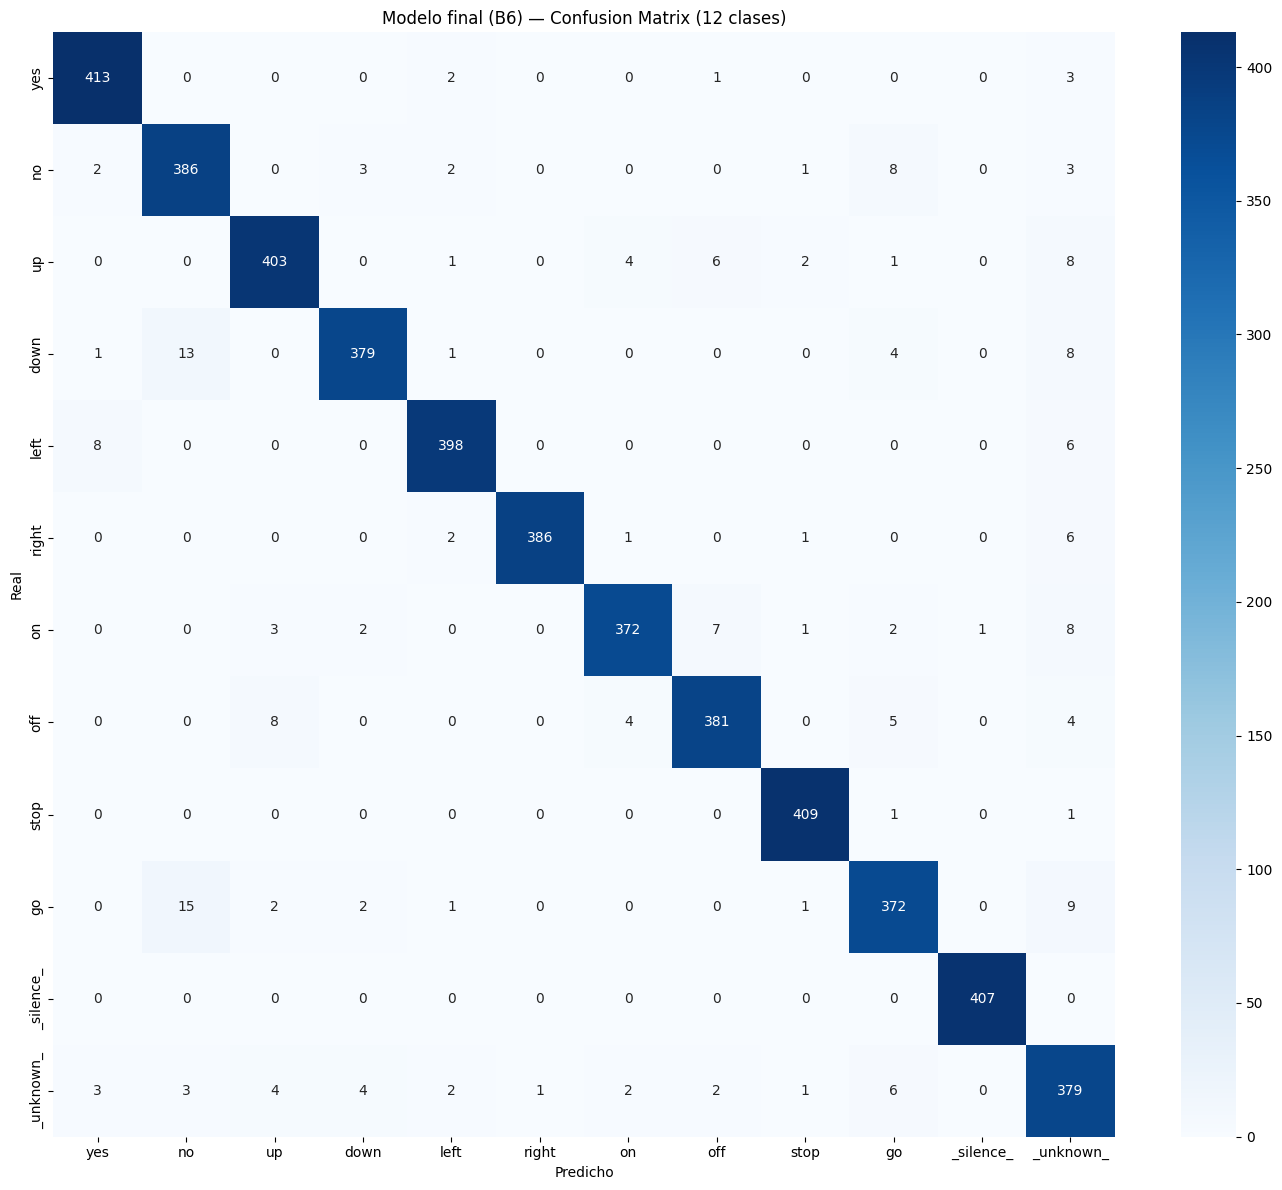

Pipeline completo ✓


In [16]:
best_model.to(DEVICE)
_, test_acc, test_f1, test_preds, test_labels = eval_epoch(best_model, test_loader, nn.CrossEntropyLoss())

print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1-macro: {test_f1:.4f}')
print()
print(classification_report(test_labels, test_preds, target_names=TARGET_CLASSES))

# Confusion matrix final (12×12)
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Modelo final ({best_run}) — Confusion Matrix (12 clases)')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150)
plt.show()
print('Pipeline completo ✓')


In [17]:
# ── Descargar archivos desde Colab ──────────────────────────────────────────
# Ejecuta esta celda al final para descargar los 2 archivos que necesita la app
from google.colab import files

print('Descargando kws_model.onnx...')
files.download('kws_model.onnx')

print('Descargando norm_stats.json...')
files.download('norm_stats.json')

print()
print('Coloca ambos archivos en:')
print('  app/assets/models/kws_model.onnx')
print('  app/assets/models/norm_stats.json')


Descargando kws_model.onnx...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando norm_stats.json...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Coloca ambos archivos en:
  app/assets/models/kws_model.onnx
  app/assets/models/norm_stats.json
